In [1]:
import numpy as np
from datetime import date
from matplotlib import pyplot as plt
import xarray as xr

In [ ]:
ds_nday_obs = xr.open_dataset('path/n_days_OBS_1984_2017.nc')
ds_nday_dcps = xr.open_dataset('path/n_days_IITM_DCPS_1984_2017.nc')
ds_nday_miroc = xr.open_dataset('path/n_days_MIROC6_1984_2017.nc')
ds_nday_canesm = xr.open_dataset('path/n_days_CanESM_1984_2017.nc')


In [ ]:
nday_obs_ = ds_nday_obs.__xarray_dataarray_variable__.sel(lon=slice(40, 80))


In [ ]:
nday_obs = ds_nday_obs.__xarray_dataarray_variable__.sel(lon=slice(40, 80))
nday_dcps = ds_nday_dcps.__xarray_dataarray_variable__.sel(lon=slice(40, 79.75))
nday_miroc = ds_nday_miroc.__xarray_dataarray_variable__.sel(lon=slice(40, 80))
nday_canesm = ds_nday_canesm.__xarray_dataarray_variable__.sel(lon=slice(40, 80))

nday_obs.shape, nday_dcps.shape, nday_miroc.shape, nday_canesm.shape

((160, 160), (160, 160), (160, 160), (160, 160))

In [ ]:
nday_obs = np.where(nday_obs == 0, np.nan, nday_obs)
nday_dcps = np.where(nday_dcps == 0, np.nan, nday_dcps)
nday_miroc = np.where(nday_miroc == 0, np.nan, nday_miroc)
nday_canesm = np.where(nday_canesm == 0, np.nan, nday_canesm)

In [ ]:
ds_nday_dcps_corr = xr.open_dataset('path/n_days_IITM_DCPS_bias_correct_1984_2017.nc')
ds_nday_miroc_corr = xr.open_dataset('path/n_days_MIROC6_bias_correct_1984_2017.nc')
ds_nday_canesm_corr = xr.open_dataset('path/n_days_CanESM_bias_correct_1984_2017.nc')


In [ ]:
nday_dcps_corr = ds_nday_dcps_corr.__xarray_dataarray_variable__.sel(lon=slice(40, 80))
nday_miroc_corr = ds_nday_miroc_corr.__xarray_dataarray_variable__.sel(lon=slice(40, 80))
nday_canesm_corr = ds_nday_canesm_corr.__xarray_dataarray_variable__.sel(lon=slice(40, 80))

nday_dcps_corr.shape, nday_miroc_corr.shape, nday_canesm_corr.shape

((160, 160), (160, 160), (160, 160))

In [ ]:
nday_dcps_corr = np.where(nday_dcps_corr == 0, np.nan, nday_dcps_corr)
nday_miroc_corr = np.where(nday_miroc_corr == 0, np.nan, nday_miroc_corr)
nday_canesm_corr = np.where(nday_canesm_corr == 0, np.nan, nday_canesm_corr)


In [ ]:
def calculate_rmse(obs, model):
    model = model.flatten()
    obs   = obs.flatten()
    aa = np.where(np.isnan(model.flatten()))[0]
    bb = np.where(np.isnan(obs.flatten()))[0]
    model[bb] = np.nan
    obs[aa]   = np.nan
    model     = model[~np.isnan(model)]
    obs       = obs[~np.isnan(obs)]
    mean = (np.mean((obs - model) ** 2))
    return np.sqrt(mean)

In [ ]:
rmse_dcps_nday = calculate_rmse(nday_obs.values, nday_dcps.values)
rmse_miroc_nday = calculate_rmse(nday_obs.values, nday_miroc.values)
rmse_canesm_nday = calculate_rmse(nday_obs.values, nday_canesm.values)

rmse_dcps_nday, rmse_miroc_nday, rmse_canesm_nday

(268.7886454772597, 281.930532085255, 328.89710040717904)

In [ ]:
rmse_dcps_nday_corr = calculate_rmse(nday_obs.values, nday_dcps_corr.values)
rmse_miroc_nday_corr = calculate_rmse(nday_obs.values, nday_miroc_corr.values)
rmse_canesm_nday_corr = calculate_rmse(nday_obs.values, nday_canesm_corr.values)

rmse_dcps_nday_corr, rmse_miroc_nday_corr, rmse_canesm_nday_corr

(190.24821132946954, 211.87138898102782, 223.6057856648895)

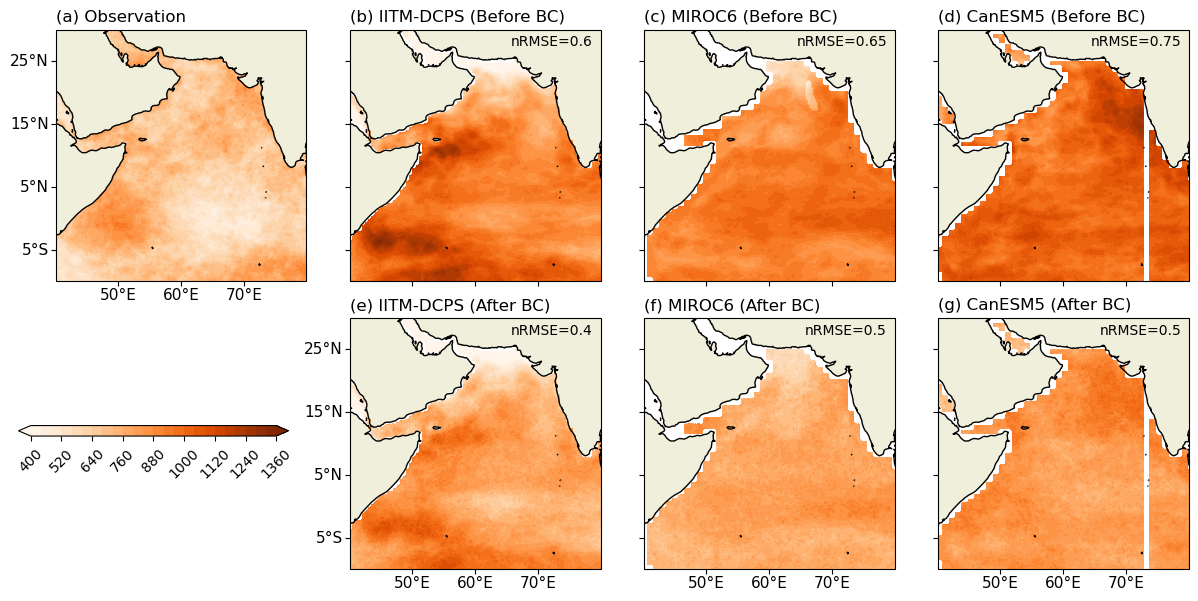

In [ ]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import cartopy


gs = gridspec.GridSpec(2,4)
fig = plt.figure(figsize = (15,7))
gs.update(wspace=0.05, hspace=0.15)
cm = 180

level_days = np.arange(400,1400,40)

col_day = 'Oranges'

transform_= ccrs.PlateCarree(central_longitude=cm)

x, y = np.meshgrid(nday_obs_.lon, nday_obs_.lat)

ax = fig.add_subplot(gs[0,0], projection=transform_)
cs = ax.contourf(x, y, nday_obs,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())
ax.set_title('(a) Observation',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = True
gl.ylabels_left  = True
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

ax = fig.add_subplot(gs[0,1], projection=transform_)
cs = ax.contourf(x, y, nday_dcps,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())
ax.set_title('(b) IITM-DCPS (Before BC)',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
# fig.text(0.915, 0.6, 'IITM-DCPS', va='center', ha='center', fontsize=12, fontweight='bold', rotation=270)
ax.text(0.97, 0.98, 'nRMSE=0.6', transform=ax.transAxes, fontsize=10, fontweight='medium', ha='right', va='top')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = False
gl.ylabels_left  = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

ax = fig.add_subplot(gs[0,2], projection=transform_)
cs = ax.contourf(x, y, nday_miroc,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())
ax.set_title('(c) MIROC6 (Before BC)',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
# fig.text(0.915, 0.4, 'MIROC6', va='center', ha='center', fontsize=12, fontweight='bold', rotation=270)
ax.text(0.97, 0.98, 'nRMSE=0.65', transform=ax.transAxes, fontsize=10, fontweight='medium', ha='right', va='top')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = False
gl.ylabels_left  = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

ax = fig.add_subplot(gs[0,3], projection=transform_)
cs = ax.contourf(x, y, nday_canesm,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())

ax.set_title('(d) CanESM5 (Before BC)',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
# fig.text(0.915, 0.2, 'CanESM5', va='center', ha='center', fontsize=12, fontweight='bold', rotation=270)
ax.text(0.97, 0.98, 'nRMSE=0.75', transform=ax.transAxes, fontsize=10, fontweight='medium', ha='right', va='top')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = False
gl.ylabels_left  = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

ax = fig.add_subplot(gs[1,1], projection=transform_)
cs = ax.contourf(x, y, nday_dcps_corr,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())
ax.set_title('(e) IITM-DCPS (After BC)',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
# fig.text(0.915, 0.77, 'IITM-DCPS', va='center', ha='center', fontsize=12, fontweight='bold', rotation=270)
ax.text(0.97, 0.98, 'nRMSE=0.4', transform=ax.transAxes, fontsize=10, fontweight='medium', ha='right', va='top')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = True
gl.ylabels_left  = True
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

ax = fig.add_subplot(gs[1,2], projection=transform_)
cs = ax.contourf(x, y, nday_miroc_corr,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())
ax.set_title('(f) MIROC6 (After BC)',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
# fig.text(0.915, 0.5, 'MIROC6', va='center', ha='center', fontsize=12, fontweight='bold', rotation=270)
ax.text(0.97, 0.98, 'nRMSE=0.5', transform=ax.transAxes, fontsize=10, fontweight='medium', ha='right', va='top')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = True
gl.ylabels_left  = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

ax = fig.add_subplot(gs[1,3], projection=transform_)
cs = ax.contourf(x, y, nday_canesm_corr,
                        levels=level_days,
                        extend='both',
                        cmap=col_day,
                        transform=ccrs.PlateCarree())

ax.set_title('(g) CanESM5 (After BC)',loc='left', fontdict={'fontsize': 12, 'fontweight': 'medium'})
# fig.text(0.915, 0.25, 'CanESM5', va='center', ha='center', fontsize=12, fontweight='bold', rotation=270)
ax.text(0.97, 0.98, 'nRMSE=0.5', transform=ax.transAxes, fontsize=10, fontweight='medium', ha='right', va='top')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,xlocs=[50,60,70],ylocs=[-5,5,15,25])
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.set_yticks([-5,5,15,25])
ax.set_yticklabels([])
ax.set_xticks([50,60,70], crs=ccrs.PlateCarree())
ax.set_xticklabels([])
gl.xlabels_top    = False
gl.ylabels_right  = False
gl.xlabels_bottom = True
gl.ylabels_left  = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

cbar_ax1 = fig.add_axes([0.11 ,0.3, 0.18,0.015])
cb = plt.colorbar(cs,cax= cbar_ax1, pad=0.023,shrink=0.85,orientation='horizontal', extend="both")
cb.ax.tick_params(axis='x', labelrotation=45)

plt.savefig('/total_MHWdays_before_after_bias_corr_obs_models_westernIO.png',dpi=1200,bbox_inches='tight')